In [1]:
import os
import pandas as pd
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader,random_split
from torchvision import transforms, models
from PIL import Image


In [2]:
class EchoDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        self.mean = self.data['ESV'].mean()
        self.std = self.data['ESV'].std()
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.img_dir, row['FileName'] + ".png")
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = (row['ESV'] - self.mean) / self.std
        return image, torch.tensor(label, dtype=torch.float32)


In [3]:
transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

full_dataset = EchoDataset("dataset/es_labels.csv", "dataset/ES", transform)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)


In [4]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

criterion = nn.SmoothL1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [24]:
for epoch in range(15):
    model.train()
    train_loss = 0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/15 [Train]"):
        imgs, labels = imgs.to(device), labels.to(device).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss, mae = 0, 0
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/15 [Val]"):
            imgs, labels = imgs.to(device), labels.to(device).unsqueeze(1)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            mae += torch.sum(torch.abs(outputs - labels)).item()
    val_loss /= len(val_loader.dataset)
    mae /= len(val_loader.dataset)

    print(f"Epoch {epoch+1}/15 | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | MAE: {mae * full_dataset.std:.2f} mL")
torch.save(model.state_dict(), "edv_model2.pth")
print("Model saved as edv_model2.pth")


Epoch 1/15 [Val]: 100%|██████████| 126/126 [00:03<00:00, 35.66it/s]


Epoch 1/15 | Train Loss: 0.3134 | Val Loss: 0.2435 | MAE: 24.72 mL


Epoch 2/15 [Val]: 100%|██████████| 126/126 [00:03<00:00, 41.72it/s]


Epoch 2/15 | Train Loss: 0.2305 | Val Loss: 0.2154 | MAE: 23.01 mL


Epoch 3/15 [Val]: 100%|██████████| 126/126 [00:02<00:00, 43.28it/s]


...

Epoch 8/15 | Train Loss: 0.1517 | Val Loss: 0.2025 | MAE: 22.34 mL


Epoch 9/15 [Val]: 100%|██████████| 126/126 [00:03<00:00, 40.37it/s]


Epoch 9/15 | Train Loss: 0.1484 | Val Loss: 0.2053 | MAE: 23.49 mL


Epoch 10/15 [Train]:  21%|██        | 105/502 [00:07<00:29, 13.47it/s]


KeyboardInterrupt: 

Epoch 1/15 Val: 100%|██████████| 126/126 [00:09<00:00, 13.89it/s]


Epoch 1 | Train Loss 0.2277 | Val Loss 0.1883 | MAE 16.19 mL


Epoch 2/15 Val: 100%|██████████| 126/126 [00:11<00:00, 10.76it/s]


Epoch 2 | Train Loss 0.1620 | Val Loss 0.1715 | MAE 15.39 mL


Epoch 3/15 Val: 100%|██████████| 126/126 [00:12<00:00, 10.00it/s]


...

Epoch 13 | Train Loss 0.0389 | Val Loss 0.1561 | MAE 14.44 mL


Epoch 14/15 Val: 100%|██████████| 126/126 [00:16<00:00,  7.67it/s]


Epoch 14 | Train Loss 0.0369 | Val Loss 0.1577 | MAE 14.42 mL


Epoch 15/15 Val: 100%|██████████| 126/126 [00:15<00:00,  8.36it/s]


Epoch 15 | Train Loss 0.0381 | Val Loss 0.1597 | MAE 14.75 mL
Model saved


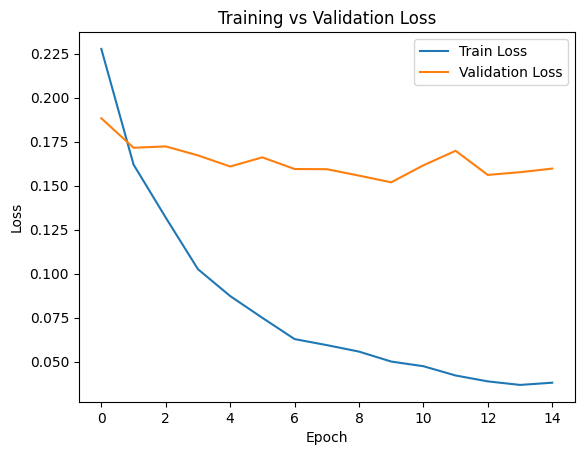

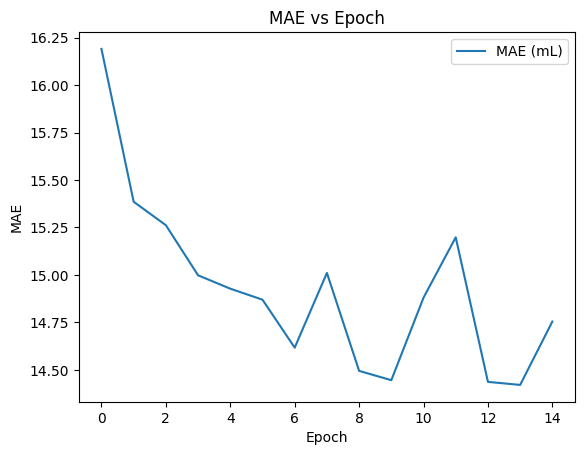

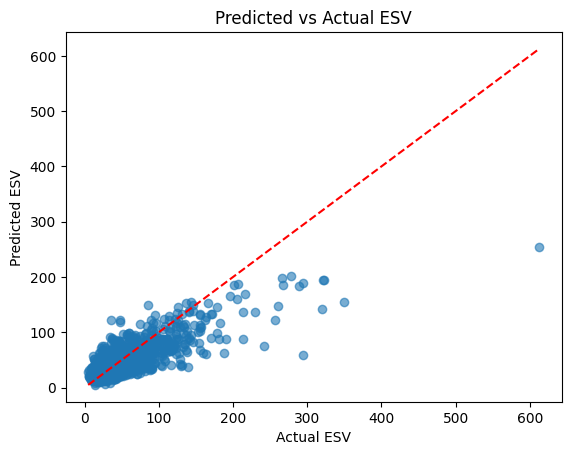

In [6]:
import os
import pandas as pd
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# -----------------------------
# Dataset
# -----------------------------
class EchoDataset(Dataset):
    
    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        
        self.mean = self.data["ESV"].mean()
        self.std = self.data["ESV"].std()
    
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        
        row = self.data.iloc[idx]
        img_path = os.path.join(self.img_dir, row["FileName"] + ".png")

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = (row["ESV"] - self.mean) / self.std

        return image, torch.tensor(label, dtype=torch.float32)


# -----------------------------
# Data Augmentation
# -----------------------------
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(10, translate=(0.05,0.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])


dataset = EchoDataset("dataset/es_labels.csv","dataset/ES",train_transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset,[train_size,val_size])

val_ds.dataset.transform = val_transform

train_loader = DataLoader(train_ds,batch_size=16,shuffle=True)
val_loader = DataLoader(val_ds,batch_size=16,shuffle=False)


# -----------------------------
# EfficientNet Model
# -----------------------------
model = models.efficientnet_b0(weights="IMAGENET1K_V1")

model.classifier[1] = nn.Linear(model.classifier[1].in_features,1)

model = model.to(device)

criterion = nn.SmoothL1Loss()

optimizer = optim.Adam(model.parameters(),lr=1e-4,weight_decay=1e-4)


# -----------------------------
# Training
# -----------------------------
epochs = 15

train_losses = []
val_losses = []
mae_scores = []

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for imgs,labels in tqdm(train_loader,desc=f"Epoch {epoch+1}/{epochs} Train"):

        imgs,labels = imgs.to(device),labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()*imgs.size(0)

    train_loss /= len(train_loader.dataset)


    model.eval()

    val_loss = 0
    mae = 0

    preds = []
    targets = []

    with torch.no_grad():

        for imgs,labels in tqdm(val_loader,desc=f"Epoch {epoch+1}/{epochs} Val"):

            imgs,labels = imgs.to(device),labels.to(device).unsqueeze(1)

            outputs = model(imgs)

            loss = criterion(outputs,labels)

            val_loss += loss.item()*imgs.size(0)

            mae += torch.sum(torch.abs(outputs-labels)).item()

            preds.extend(outputs.cpu().numpy())
            targets.extend(labels.cpu().numpy())

    val_loss /= len(val_loader.dataset)
    mae /= len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    mae_scores.append(mae * dataset.std)

    print(f"Epoch {epoch+1} | Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | MAE {(mae*dataset.std):.2f} mL")


torch.save(model.state_dict(),"esv_model_efficientnet.pth")

print("Model saved")



plt.figure()

plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()



plt.figure()

plt.plot(mae_scores,label="MAE (mL)")

plt.xlabel("Epoch")
plt.ylabel("MAE")

plt.title("MAE vs Epoch")

plt.legend()

plt.show()


preds = np.array(preds) * dataset.std + dataset.mean
targets = np.array(targets) * dataset.std + dataset.mean

plt.figure()

plt.scatter(targets,preds,alpha=0.6)

plt.xlabel("Actual ESV")
plt.ylabel("Predicted ESV")

plt.title("Predicted vs Actual ESV")

plt.plot([targets.min(),targets.max()],
[targets.min(),targets.max()],
'r--')

plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt

model.eval()

preds = []
targets = []

with torch.no_grad():

    for imgs, labels in val_loader:

        imgs = imgs.to(device)

        outputs = model(imgs).cpu().numpy()

        preds.extend(outputs)
        targets.extend(labels.numpy())



preds = np.array(preds) * dataset.std + dataset.mean
targets = np.array(targets) * dataset.std + dataset.mean


plt.figure()

plt.scatter(targets, preds, alpha=0.6)

plt.plot(
    [targets.min(), targets.max()],
    [targets.min(), targets.max()],
    'r--'
)

plt.xlabel("Actual EDV (mL)")
plt.ylabel("Predicted EDV (mL)")
plt.title("Predicted vs Actual EDV")

plt.show()



plt.figure()

plt.plot(targets[200:300], label="Actual", marker='o')
plt.plot(preds[200:300], label="Predicted", marker='x')

plt.xlabel("Sample")
plt.ylabel("EDV (mL)")
plt.title("Actual vs Predicted EDV")

plt.legend()

plt.show()

NameError: name 'model' is not defined

In [3]:
mean_vals = (preds + targets) / 2
diff_vals = preds - targets

plt.figure()

plt.scatter(mean_vals, diff_vals, alpha=0.6)

plt.axhline(np.mean(diff_vals), linestyle='--')
plt.axhline(np.mean(diff_vals) + 1.96*np.std(diff_vals), linestyle='--')
plt.axhline(np.mean(diff_vals) - 1.96*np.std(diff_vals), linestyle='--')

plt.xlabel("Mean of Actual & Predicted")
plt.ylabel("Difference")

plt.title("Bland-Altman Plot")

plt.show()

NameError: name 'preds' is not defined

In [13]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SimpleDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.paths = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(('.png','.jpg','.jpeg'))]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = 0
        return img, label

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = SimpleDataset("dataset/ES", transform=transform)
subset = Subset(dataset, list(range(min(50, len(dataset)))))
loader = DataLoader(subset, batch_size=32, shuffle=False)

model = models.efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)

model.load_state_dict(torch.load("esv_model_efficientnet.pth", map_location=device))
model.to(device)
model.eval()

preds = []
targets = []

with torch.no_grad():
    for imgs, labels in loader:
        imgs = imgs.to(device)
        outputs = model(imgs).cpu().numpy()
        preds.extend(outputs)
        targets.extend(labels.numpy())

preds = np.array(preds).flatten()
targets = np.array(targets).flatten()

mae = mean_absolute_error(targets, preds)
mse = mean_squared_error(targets, preds)

print(mae, mse)

0.6901634335517883 1.0116543769836426
